In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [30]:
df_train = pd.read_csv("comment-category-prediction-challenge/train.csv") 
df_test = pd.read_csv("comment-category-prediction-challenge/test.csv") 

df_test["is_train"] = 0
df_train["is_train"] = 1
sample = pd.read_csv("comment-category-prediction-challenge/Sample.csv") 

In [31]:
df_train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,is_train
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals.,2,1
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not bound to tribal court.. Living in a particular community does not change your rights under state and federal law. In this case, Connor can basically flip the bird to the tribal court and there's nothing they can actually do. The only courts it appears he is subject to are those formally established under state and federal law, which does not recognize this.\n\nThe tribal court can at-best basically use it's influence to get tribal members and others in the community to refuse to associate with Connor and not do business with him, essentially acting like a shunning until Connor decides to leave.",0,1
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,"in the future please spare me your strawman drivel, and if you can't manage an intelligent discussion, stick to posting on a public bathroom wall. That is not remotely what I believe. That's the mindless drivel your thoughts produced. Nor did I get the idea every prediction must come true for it to be true, again, that is the mindless drivel your thoughts produced. What I did state is every computer model as been proven wrong, time, and time again, and every fear mongering prediction herding sheep has failed to come to fruition. What you fail to understand in speaking in ignorance is the fact since I was 8 years old I have advocated ouf for stronger EPA laws, which has nothing to do with this ridiculous nonsense of "" manmade global warming.""",2,1
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""corruption"". But really, either one works. olae",2,1
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the nazi flag...school children don't have the same free speech rights in, on or near public school property as adults in public... maybe you don't remember ""Bong hits for Jesus""...perhaps ya outta get out more. ep",2,1


### Let's start with feature engi and EDA on both train and test data

In [32]:
df = pd.concat([df_train, df_test], ignore_index=True) #merged it so we can perform essentail eda and fe on both datasets
df

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,is_train
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals.,2.0,1
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not bound to tribal court.. Living in a particular community does not change your rights under state and federal law. In this case, Connor can basically flip the bird to the tribal court and there's nothing they can actually do. The only courts it appears he is subject to are those formally established under state and federal law, which does not recognize this.\n\nThe tribal court can at-best basically use it's influence to get tribal members and others in the community to refuse to associate with Connor and not do business with him, essentially acting like a shunning until Connor decides to leave.",0.0,1
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,"in the future please spare me your strawman drivel, and if you can't manage an intelligent discussion, stick to posting on a public bathroom wall. That is not remotely what I believe. That's the mindless drivel your thoughts produced. Nor did I get the idea every prediction must come true for it to be true, again, that is the mindless drivel your thoughts produced. What I did state is every computer model as been proven wrong, time, and time again, and every fear mongering prediction herding sheep has failed to come to fruition. What you fail to understand in speaking in ignorance is the fact since I was 8 years old I have advocated ouf for stronger EPA laws, which has nothing to do with this ridiculous nonsense of "" manmade global warming.""",2.0,1
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""corruption"". But really, either one works. olae",2.0,1
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the nazi flag...school children don't have the same free speech rights in, on or near public school property as adults in public... maybe you don't remember ""Bong hits for Jesus""...perhaps ya outta get out more. ep",2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,2023-09-26 03:14:06.328881+00:00,72,0,0,0,1,0,0,4,NaN,NaN,NaN,False,"Working in McDonald's is easy (pain in the posterior but easy).. Try working in the fields picking strawberries and tomatoes in 90 degree weather.\n\nAnd many of those McDonald's jobs are going to disappear in the near future - touch screens to order food, hamburger machines to make them, and voila - no jobs.",NaN,0
299996,2023-08-18 19:30:16.601996+00:00,71,2,0,0,1,0,10,4,none,christian,female,False,"In support of your first sentence, please provide support - that the Catholic Church, the Orthdox Communion, or the Oriental Orthodox have ever ordained women - that any women ordained by schismatic sects outside these communions have ever been sxyzf recognized as clerics in orders",NaN,0
299997,2023-10-26 15:41:55.972421+00:00,72,0,0,0,0,5,4,4,none,none,none,False,Cry us a river..\n\nhttp://www.celebritynetworth.com/richest-celebrities/singers/ron-sexsmith-net-worth/\n.,NaN,0
299998,2024-02-28 11:25:10.033561+00:00,72,1,0,0,0,0,0,4,NaN,NaN,NaN,False,tggv What does that have to do with Trudeau not cancelling the deal?,NaN,0


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   created_date  300000 non-null  str    
 1   post_id       300000 non-null  int64  
 2   emoticon_1    300000 non-null  int64  
 3   emoticon_2    300000 non-null  int64  
 4   emoticon_3    300000 non-null  int64  
 5   upvote        300000 non-null  int64  
 6   downvote      300000 non-null  int64  
 7   if_1          300000 non-null  int64  
 8   if_2          300000 non-null  int64  
 9   race          79308 non-null   str    
 10  religion      79308 non-null   str    
 11  gender        79308 non-null   str    
 12  disability    300000 non-null  bool   
 13  comment       299999 non-null  str    
 14  label         198000 non-null  float64
 15  is_train      300000 non-null  int64  
dtypes: bool(1), float64(1), int64(9), str(5)
memory usage: 34.6 MB


In [34]:
display(df['race'].unique())
display(df['religion'].unique())
display(df['gender'].unique())
display(df['disability'].unique())
display(df['created_date'].unique())

<StringArray>
[nan, 'none', 'white', 'other', 'asian', 'black', 'latino']
Length: 7, dtype: str

<StringArray>
[        nan, 'christian',    'muslim',      'none',    'jewish',   'atheist',
     'other',     'hindu',  'buddhist']
Length: 9, dtype: str

<StringArray>
[nan, 'none', 'male', 'female', 'transgender', 'other']
Length: 6, dtype: str

array([False,  True])

<StringArray>
['2024-01-18 08:43:57.397508+00:00', '2024-03-24 21:43:11.490017+00:00',
 '2024-04-24 20:32:17.014931+00:00', '2023-05-28 22:00:14.214527+00:00',
 '2023-09-09 23:12:05.689498+00:00', '2024-04-06 20:10:59.141468+00:00',
 '2024-03-04 03:02:55.849172+00:00', '2023-10-14 20:57:30.208573+00:00',
 '2024-02-24 12:13:22.166045+00:00', '2023-08-07 20:35:35.968324+00:00',
 ...
 '2023-11-11 05:04:03.749590+00:00', '2024-04-06 08:41:04.924689+00:00',
 '2024-04-30 19:10:35.930782+00:00', '2024-05-04 07:53:11.994478+00:00',
 '2023-06-16 18:43:17.385957+00:00', '2023-09-26 03:14:06.328881+00:00',
 '2023-08-18 19:30:16.601996+00:00', '2023-10-26 15:41:55.972421+00:00',
 '2024-02-28 11:25:10.033561+00:00', '2022-12-30 06:10:30.575151+00:00']
Length: 299982, dtype: str

In [35]:
df[~df['race'].isna()]

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,is_train
8,2024-02-24 12:13:22.166045+00:00,71,0,0,0,0,0,6,6,none,christian,none,False,"I wonder what our ancestors would say when they saw how many ""Catholics"" today support abortion and homosexual behavior.. I'm sure they'd be disgusted. And rightfully so.",0.0,1
10,2023-12-26 01:06:22.590457+00:00,120,0,0,0,1,0,4,10,none,muslim,none,False,You're right the words Muslim ban came straight from trump.,1.0,1
12,2023-05-08 22:41:58.194759+00:00,31,0,0,0,2,0,4,10,none,none,none,False,"Trump doesn't grasp even the little picture. He isn't even a slow learner but a non-learner when it comes to nxoy boundaries relative to think before you speak - none, nada, zero ... no matter how many times he has had to backtrack or been told. I have thought from the beginning he did not want the Presidency just the attention and joy of the ride. He has from the beginning been saying stupid things that are exactly what a candidate would say who DOES NOT want to be elected. This could be his best seller yet...How Not To Get Elected to ANY Office by Donald Trump. For me I have an underlying frustration and disappointment in the voters who selected him...which wasn't anyone in Oregon since he was already chosen. What were you thinking? He was toying with you saying do not vote for me with his myriad of Trumpisms and yet you did. The Trump Trap...tell them I will do the things they want, like all politicians do, BUT act and say what I want NOW before the vote, cause I want to be me.",2.0,1
15,2024-03-13 02:27:09.785460+00:00,73,0,0,0,0,0,4,4,none,none,none,False,I believe its 1200 noon HST broadcast. rv,0.0,1
16,2023-07-12 03:19:48.796102+00:00,39,0,0,0,0,0,4,10,none,none,none,False,"I did Google it.. Everything I read says it is a REPRESENTATIVE democracy, consistent with the definition I posted above. Don, Lisa, and Dan are our REPRESENTATIVES in Washington. \nYou don't have to remain ignorant unless you want to.",2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299966,2024-02-09 06:29:46.354475+00:00,72,0,0,0,3,1,4,4,none,none,none,False,"With all this talk of Trump , Paris agreement , climate change, maybe somebody should have told him how much warming it is going to prevent in the next 80 odd years.\nUnless , if it will not prevent any measurable or significant amount at all, that would be embarrassing for those advocating for it..&...kind of hard to explain it too thosep aying for it.\nSince it is a temperature never mentioned ,I'm betting on 'it will not prevent any measurable/significant amount at all, '",NaN,0
299973,2023-11-06 20:20:14.259119+00:00,31,0,0,1,0,1,4,10,black,none,none,False,"If I were black and wanted to feel safe, I'd move to Chicago..",NaN,0
299975,2023-04-11 19:39:24.171321+00:00,39,0,0,0,12,0,10,10,none,muslim,female,False,"Clinton is wrong. Half of Trump's supporters are not ""racist, sexist, zwhla homophobic, xenophobic, Islamophobic"". The percentage is much higher.",NaN,0
299996,2023-08-18 19:30:16.601996+00:00,71,2,0,0,1,0,10,4,none,christian,female,False,"In support of your first sentence, please provide support - that the Catholic Church, the Orthdox Communion, or the Oriental Orthodox have ever ordained women - that any women ordained by schismatic sects outside these communions have ever been sxyzf recognized as clerics in orders",NaN,0


In [36]:
df['created_date'] = pd.to_datetime(df['created_date'], yearfirst=True)

In [37]:
# creating separate day, month, year
df['Day'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.day.astype(int)
df['Month'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.month.astype(int)
df['Year'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.year.astype(int)
df

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,is_train,Day,Month,Year
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals.,2.0,1,18,1,2024
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not bound to tribal court.. Living in a particular community does not change your rights under state and federal law. In this case, Connor can basically flip the bird to the tribal court and there's nothing they can actually do. The only courts it appears he is subject to are those formally established under state and federal law, which does not recognize this.\n\nThe tribal court can at-best basically use it's influence to get tribal members and others in the community to refuse to associate with Connor and not do business with him, essentially acting like a shunning until Connor decides to leave.",0.0,1,24,3,2024
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,"in the future please spare me your strawman drivel, and if you can't manage an intelligent discussion, stick to posting on a public bathroom wall. That is not remotely what I believe. That's the mindless drivel your thoughts produced. Nor did I get the idea every prediction must come true for it to be true, again, that is the mindless drivel your thoughts produced. What I did state is every computer model as been proven wrong, time, and time again, and every fear mongering prediction herding sheep has failed to come to fruition. What you fail to understand in speaking in ignorance is the fact since I was 8 years old I have advocated ouf for stronger EPA laws, which has nothing to do with this ridiculous nonsense of "" manmade global warming.""",2.0,1,24,4,2024
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""corruption"". But really, either one works. olae",2.0,1,28,5,2023
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the nazi flag...school children don't have the same free speech rights in, on or near public school property as adults in public... maybe you don't remember ""Bong hits for Jesus""...perhaps ya outta get out more. ep",2.0,1,9,9,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,2023-09-26 03:14:06.328881+00:00,72,0,0,0,1,0,0,4,NaN,NaN,NaN,False,"Working in McDonald's is easy (pain in the posterior but easy).. Try working in the fields picking strawberries and tomatoes in 90 degree weather.\n\nAnd many of those McDonald's jobs are going to disappear in the near future - touch screens to order food, hamburger machines to make them, and voila - no jobs.",NaN,0,26,9,2023
299996,2023-08-18 19:30:16.601996+00:00,71,2,0,0,1,0,10,4,none,christian,female,False,"In support of your first sentence, please provide support - that the Catholic Church, the Orthdox Communion, or the Oriental Orthodox have ever ordained women - that any women ordained by schismatic sects outside these communions have ever been sxyzf recognized as clerics in orders",NaN,0,18,8,2023
299997,2023-10-26 15:41:55.972421+00:00,72,0,0,0,0,5,4,4,none,none,none,False,Cry us a river..\n\nhttp://www.celebritynetworth.com/richest-celebrities/singers/ron-sexsmith-net-worth/\n.,NaN,0,26,10,2023
299998,2024-02-28 11:25:10.033561+00:00,72,1,0,0,0,0,0,4,NaN,NaN,NaN,False,tggv What does that have to do with Trudeau not cancelling the deal?,NaN,0,28,2,2024


In [38]:
df['weekday'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.weekday.astype(int)

In [39]:
df['weekend'] = df['weekday'].isin([5,6]).astype(int) #to fetch the weekends
df['created_hour'] = pd.to_datetime(df['created_date']).dt.hour

In [40]:
df.post_id.unique()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   created_date  300000 non-null  datetime64[us, UTC]
 1   post_id       300000 non-null  int64              
 2   emoticon_1    300000 non-null  int64              
 3   emoticon_2    300000 non-null  int64              
 4   emoticon_3    300000 non-null  int64              
 5   upvote        300000 non-null  int64              
 6   downvote      300000 non-null  int64              
 7   if_1          300000 non-null  int64              
 8   if_2          300000 non-null  int64              
 9   race          79308 non-null   str                
 10  religion      79308 non-null   str                
 11  gender        79308 non-null   str                
 12  disability    300000 non-null  bool               
 13  comment       299999 non-null  str                
 14 

In [41]:
pd.get_dummies(df['race'])

,asian,black,latino,none,other,white
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
299995,False,False,False,False,False,False
299996,False,False,False,True,False,False
299997,False,False,False,True,False,False
299998,False,False,False,False,False,False


### Handling categorical features: 
race, religion, gender : categorical to numerical

In [42]:
df.isna().sum()
# race, religion, gender : categorical to numerical
cols = ['race', 'religion', 'gender']
for i in cols:
    df[i+'_missing'] = df[i].isna().astype(int)
    df[i]= df[i].fillna("Missing").astype(str)


### Handling comments:

In [43]:
# handing missing vals:
df[df['comment'].isna()]
df['comment'] = df['comment'].fillna('').astype(str)

In [44]:
df['comment_len'] = df['comment'].str.len()
df['comment'] = df['comment'].str.lower().str.split()
df['word_cnt'] = df['comment'].str.len()
# pd.set_option('display.max_colwidth', None)
# df['comment'].head()


In [76]:
df['comment']= df['comment'].str.join(" ")

In [79]:
#some text intensive features:
df['num_!'] = df['comment'].str.count('!')
df['num_ques'] = df['comment'].str.count(r'\?')

In [45]:
pd.set_option('display.max_colwidth', None)
df['comment'].head(3)

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    [she, might, be, a, bright, spot, for, a, party, keou, on, oahu, dominated, by, greedy, criminals, or, ethically, challenged, individuals.]
1    [under, alaska, law,, a, non-tribal, member, is, not, bound, to, tribal, court.., living, in, a, particular, community, does, not, change, your, rights, under, state, and, federal, law., in, this, case,, connor, can, basically, flip, the, bird, to, the, tribal, court, and, there's, nothing, they, can, act

### Handling Emojis and Imp columns

In [46]:
# df.info()
df['emoji_counts'] = df['emoticon_1']+df['emoticon_2']+df['emoticon_3']

In [47]:
s = "She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals."
s.lower()

'she might be a bright spot for a party keou on oahu dominated by greedy criminals or ethically challenged individuals.'

### Handling Votes and performing FE on them: Engagement signls

**Let's see what all can we do with it:**
1. Total votes (we can simply sum them)
2. ratio of upvotes to downvotes(get the ratio)

*These are strong internal signal that'd be useful for prediction*

In [48]:
# df.info()
# df[['upvote', 'downvote']]
df['votes_ratio'] = df['upvote']/(df['upvote']+df['downvote']+ 1e-9) #learning: to avoid inf (0/0) add 1e-9 in denominator [it's basically adding a raelly tiny number 0.0000000001 to avoid 0/0 case]


In [49]:
#  balancing the magnitude : popularity magnitude or negative feedback magnitude using logx
df['upvote_log1'] = np.log1p(df['upvote'])
df['downvote_log1'] = np.log1p(df['downvote'])


In [90]:
#engagement scorea nd intensiryt
df['engagement_score'] = df['upvote'] - df['downvote']
df['emoticon_density'] = df['emoji_counts'] / (df['word_cnt'] + 1)

In [92]:
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label', 'is_train', 'Day', 'Month', 'Year',
       'weekday', 'weekend', 'created_hour', 'race_missing',
       'religion_missing', 'gender_missing', 'comment_len', 'word_cnt',
       'emoji_counts', 'votes_ratio', 'upvote_log1', 'downvote_log1',
       'post_comments_count', 'num_!', 'num_ques', 'engagement_score',
       'emoticon_density'],
      dtype='str')

In [51]:
# df['post_id'].unique()
# df.groupby('post_id').size().
post_counts = df[df['is_train']==1].groupby('post_id').size().rename('post_comments_count')
# rest not seen will just point to 0
df['post_comments_count'] = df['post_id'].map(post_counts).fillna(0).astype(int)

In [52]:
df[:5]

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,...,race_missing,religion_missing,gender_missing,comment_len,word_cnt,emoji_counts,votes_ratio,upvote_log1,downvote_log1,post_comments_count
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,Missing,...,1,1,1,118,20,0,0.0,0.000000,0.693147,14882
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,Missing,...,1,1,1,644,110,0,1.0,1.945910,0.000000,40946
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,Missing,...,1,1,1,751,133,2,0.0,0.000000,0.000000,17023
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,Missing,...,1,1,1,91,15,0,1.0,1.791759,0.000000,40946
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,Missing,...,1,1,1,254,40,0,0.0,0.000000,0.000000,40946


In [53]:
# df.drop(['created_date'], axis = 1, inplace=True)
# df.dtypes
df.duplicated(subset=['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'label', 'is_train', 'Day', 'Month', 'Year',
       'weekday', 'race_missing', 'religion_missing', 'gender_missing',
       'comment_len', 'word_cnt', 'emoji_counts', 'votes_ratio', 'upvote_log1',
       'downvote_log1']).sum() # the comment col is list, to avoid typeerror 

np.int64(0)

In [69]:
# missing flags 
display(df.describe().T)
display(df.info())

,count,mean,std,min,25%,50%,75%,max
post_id,300000.0,68.417507,27.939911,20.0,39.0,72.000000,72.000000,129.000000
emoticon_1,300000.0,0.279873,1.030117,0.0,0.0,0.000000,0.000000,95.000000
emoticon_2,300000.0,0.048343,0.258069,0.0,0.0,0.000000,0.000000,11.000000
emoticon_3,300000.0,0.120333,0.480833,0.0,0.0,0.000000,0.000000,19.000000
upvote,300000.0,2.608460,5.024763,0.0,0.0,1.000000,3.000000,201.000000
downvote,300000.0,0.664787,2.017886,0.0,0.0,0.000000,1.000000,107.000000
if_1,300000.0,1.905107,25.854302,0.0,0.0,0.000000,4.000000,1866.000000
if_2,300000.0,7.956210,14.958419,3.0,4.0,6.000000,10.000000,1833.000000
label,198000.0,0.793965,0.979808,0.0,0.0,0.000000,2.000000,3.000000
is_train,300000.0,0.660000,0.473710,0.0,0.0,1.000000,1.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   created_date         300000 non-null  datetime64[us, UTC]
 1   post_id              300000 non-null  int64              
 2   emoticon_1           300000 non-null  int64              
 3   emoticon_2           300000 non-null  int64              
 4   emoticon_3           300000 non-null  int64              
 5   upvote               300000 non-null  int64              
 6   downvote             300000 non-null  int64              
 7   if_1                 300000 non-null  int64              
 8   if_2                 300000 non-null  int64              
 9   race                 300000 non-null  str                
 10  religion             300000 non-null  str                
 11  gender               300000 non-null  str                
 12  disability   

None

In [62]:
# outliers 
def iqr(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr  = q3 - q1
    lower, upper = q1-1.5*iqr, q3+1.5*iqr 
    return lower, upper, (s<lower).sum(), (s>upper).sum()

print("the Extreme valeus are :")
for i in ['upvote', 'downvote', 'if_1', 'if_2']:
    l,u,below,above = iqr(df[i])
    print(f"{i}: lower={l:.2f}, upper={u:.2f}, below={below}, above={above}")

# df['upvote'].quantile(0.75)

the Extreme valeus are :
upvote: lower=-4.50, upper=7.50, below=0, above=26337
downvote: lower=-1.50, upper=2.50, below=0, above=22989
if_1: lower=-6.00, upper=10.00, below=0, above=127
if_2: lower=-5.00, upper=19.00, below=0, above=5938


## Encoding categorical features:

In [ ]:
df['disability'] = df['disability'].astype(int) #0 is False and 1 is True


In [ ]:
display(df['race'].unique(),
df['religion'].unique(),
df['gender'].unique(),
df['post_id'].unique())

<StringArray>
['Missing', 'none', 'white', 'other', 'asian', 'black', 'latino']
Length: 7, dtype: str

<StringArray>
[  'Missing', 'christian',    'muslim',      'none',    'jewish',   'atheist',
     'other',     'hindu',  'buddhist']
Length: 9, dtype: str

<StringArray>
['Missing', 'none', 'male', 'female', 'transgender', 'other']
Length: 6, dtype: str

array([ 73,  39,  31,  72,  71, 120,  40, 111,  64, 123,  61, 105,  84,
       118,  76,  24,  91,  85, 102,  70,  74,  77,  66,  93, 100,  87,
        83, 103, 101, 108, 115,  79,  89,  75, 104,  90,  95,  96,  67,
       129,  82,  50,  43,  42, 109,  88, 125,  86,  20, 113,  65, 110])

In [107]:
#Splitting the train and test
train_df = df[df['is_train'] == 1].copy(deep= True)
test_df = df[df['is_train'] == 0].copy(deep= True)

In [108]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()

In [120]:
X_train = ohe.fit_transform(train_df[['race', 'religion', 'gender']]) 
X_test = ohe.fit_transform(test_df[['race', 'religion', 'gender']]) 

In [124]:
encoded_df = pd.DataFrame(X_train.toarray(), columns= ohe.get_feature_names_out(['race', 'religion', 'gender']))

# 3. View the result
display(encoded_df.head())

,race_Missing,race_asian,race_black,race_latino,race_none,race_other,race_white,religion_Missing,religion_atheist,religion_buddhist,...,religion_jewish,religion_muslim,religion_none,religion_other,gender_Missing,gender_female,gender_male,gender_none,gender_other,gender_transgender
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## visualisations and insigsts

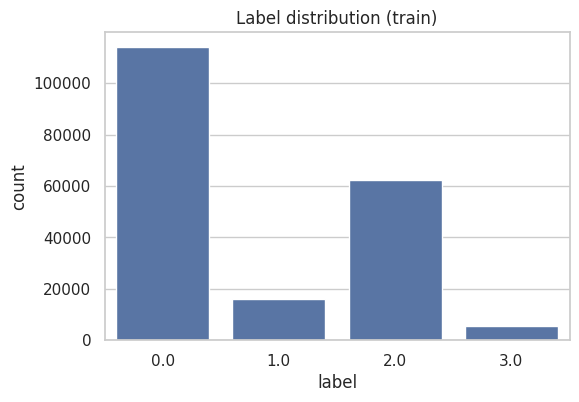

In [ ]:
import matplotlib.pyplot as plt, seaborn as sns

